In [30]:
import sys, argparse
sys.path.insert(0, "/home/yspark/rcdm/RCJiT/JiT")
sys.path.insert(0, "/home/yspark/rcdm/RCJiT/src")
sys.path.insert(0, "/home/yspark/cxr-ssl")

import torch
from train_rcjit_mae import RCJiTMAEModule, get_rcjit_aug

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

RCJIT_CKPT = "/home/yspark/cxr-ssl/output/rcjit_s16_mae_pool_cxr/checkpoints/last.ckpt"
ckpt = torch.load(RCJIT_CKPT, map_location="cpu", weights_only=False)
hparams = ckpt["hyper_parameters"]
hparams["encoder_ckpt"] = "/home/yspark/cxr-ssl/cxr-ssl/ssnlqx8u/checkpoints/epoch=799-step=576000.ckpt"

args = argparse.Namespace(**hparams)
rcjit_lit = RCJiTMAEModule(args)
rcjit_lit.load_state_dict(ckpt["state_dict"], strict=False)
rcjit_lit.eval()

denoiser = rcjit_lit.denoiser.to(DEVICE)
print("RCJiT denoiser loaded  step:", ckpt["global_step"])
print("ctx_mode:", denoiser.ctx_mode, " steps:", denoiser.steps, " method:", denoiser.method)

RCJiT denoiser loaded  step: 300000
ctx_mode: pool  steps: 50  method: heun


In [31]:
from torch.utils.data import DataLoader
from mimic_cxr import MIMICCXRDataset
from stable_pretraining.data.datasets import FromTorchDataset

cpu_transform_rcjit, gpu_aug_rcjit = get_rcjit_aug(DEVICE)

dataset_rcjit = FromTorchDataset(
    dataset=MIMICCXRDataset(
        root="/mnt/nvme1/mimic-cxr-jpg",
        split="validate",
        label_csv="chexpert",
        transform=None,
        frontal_only=False,
        uncertainty="zero",
    ),
    names=["image", "labels"],
    transform=cpu_transform_rcjit,
    gpu_transform=None,
)
loader_rcjit = DataLoader(
    dataset_rcjit, batch_size=8, shuffle=False, num_workers=4, pin_memory=True
)
print(f"Val samples (all views): {len(dataset_rcjit)}")

Val samples (all views): 2991


In [32]:
import torchvision.transforms.functional as TF_vis
from tqdm.auto import tqdm

denoiser.steps = 50

def det_aug(imgs):
    """(B,3,256,256) [0,1]  →  (B,3,224,224) [-1,1]  (center crop, no random)"""
    return TF_vis.center_crop(imgs, 224) * 2.0 - 1.0

all_h  = []   # cls(x)   for all x
all_hp = []   # cls(x')  for all x

with torch.no_grad():
    for batch in tqdm(loader_rcjit):
        imgs = batch["image"].to(DEVICE)
        imgs = det_aug(imgs)

        cls_x,  _ = denoiser.encode_dino(imgs)
        x_prime   = denoiser.generate(imgs)
        cls_xp, _ = denoiser.encode_dino(x_prime)

        all_h .append(cls_x .cpu())
        all_hp.append(cls_xp.cpu())

all_h  = torch.cat(all_h ).float()   # (N, D)
all_hp = torch.cat(all_hp).float()   # (N, D)
N = len(all_h)
print(f"h  matrix: {all_h.shape}")
print(f"h' matrix: {all_hp.shape}")


  0%|          | 0/374 [00:00<?, ?it/s]/home/yspark/miniconda3/lib/python3.13/site-packages/lance/__init__.py:320: UserWarning: lance is not fork-safe. If you are using multiprocessing, use spawn or forkserver instead.
  warnings.warn(
100%|██████████| 374/374 [06:07<00:00,  1.02it/s]/home/yspark/miniconda3/lib/python3.13/site-packages/lance/__init__.py:320: UserWarning: lance is not fork-safe. If you are using multiprocessing, use spawn or forkserver instead.
  warnings.warn(


h  matrix: torch.Size([2991, 384])
h' matrix: torch.Size([2991, 384])


In [33]:
# ── pairwise 거리 + nearest-neighbor 분석 ────────────────────────────────────
# dist_hh[i,j] = ||h_i - h_j||   (N×N, 대각=0)
# dist_hhp[i]  = ||h_i - h'_i||  (N,)

sq     = (all_h ** 2).sum(1, keepdim=True)                          # (N,1)
dist_hh = (sq + sq.T - 2 * all_h @ all_h.T).clamp(0).sqrt()        # (N,N)

sq_hp   = (all_hp ** 2).sum(1, keepdim=True)
dist_hhp = (sq + sq_hp - 2 * (all_h * all_hp).sum(1, keepdim=True)).clamp(0).sqrt().squeeze(1)  # (N,)

# inter-sample (대각 제외)
mask_off  = ~torch.eye(N, dtype=torch.bool)
inter     = dist_hh[mask_off]

print("=== 거리 분포 비교 ===")
print(f"inter-sample ||hi-hj||  mean={inter.mean():.4f}  std={inter.std():.4f}  "
      f"min={inter.min():.4f}  max={inter.max():.4f}")
print(f"||h - h'||              mean={dist_hhp.mean():.4f}  std={dist_hhp.std():.4f}  "
      f"min={dist_hhp.min():.4f}  max={dist_hhp.max():.4f}")
print(f"  ratio (h-h') / inter : {dist_hhp.mean() / inter.mean():.3f}x")

# ── Nearest-neighbor retrieval ────────────────────────────────────────────────
# h' 각각에 대해 모든 h 중 가장 가까운 것을 찾아 인덱스 확인
# dist(h'_i, h_j) for all j
sq_p  = (all_hp ** 2).sum(1, keepdim=True)                          # (N,1)
dist_hph = (sq_p + sq.T - 2 * all_hp @ all_h.T).clamp(0).sqrt()    # (N,N)  [i,j]=||h'_i - h_j||

nn_idx   = dist_hph.argmin(dim=1)                  # (N,) : h'_i의 nearest neighbor index
correct  = (nn_idx == torch.arange(N))             # h'_i → h_i 이면 True

# rank of h_i among all h for query h'_i
ranks = (dist_hph.argsort(dim=1) == torch.arange(N).unsqueeze(1)).nonzero(as_tuple=True)[1] + 1

print()
print("=== Nearest-neighbor retrieval (h' → h) ===")
print(f"Top-1 accuracy : {correct.float().mean()*100:.1f}%  ({correct.sum().item()}/{N})")
print(f"Median rank    : {ranks.float().median():.1f}  (of {N})")
print(f"Mean rank      : {ranks.float().mean():.1f}")
print(f"Rank ≤5        : {(ranks<=5).float().mean()*100:.1f}%")
print(f"Rank ≤10       : {(ranks<=10).float().mean()*100:.1f}%")

=== 거리 분포 비교 ===
inter-sample ||hi-hj||  mean=1.9528  std=0.4176  min=0.0207  max=5.2945
||h - h'||              mean=1.5853  std=0.2711  min=0.9681  max=3.2061
  ratio (h-h') / inter : 0.812x

=== Nearest-neighbor retrieval (h' → h) ===
Top-1 accuracy : 48.4%  (1447/2991)
Median rank    : 2.0  (of 2991)
Mean rank      : 14.0
Rank ≤5        : 73.0%
Rank ≤10       : 80.7%


In [34]:
import pandas as pd
import numpy as np

meta = pd.read_csv("/mnt/nvme1/mimic-cxr-jpg/mimic-cxr-2.0.0-metadata.csv.gz",
                   usecols=["dicom_id", "ViewPosition"])
df = dataset_rcjit.dataset.df.merge(meta, on="dicom_id", how="left")
views       = df["ViewPosition"].fillna("Unknown").values   # (N,)
subject_ids = df["subject_id"].values                       # (N,)
subj_t      = torch.from_numpy(subject_ids.astype(np.int64))

print("ViewPosition 분포:")
print(pd.Series(views).value_counts())
print()

def nn_metrics(h, hp, subj_t_sub, label):
    N = len(h)
    if N < 2:
        print(f"[{label}] N={N} — skip")
        return
    sq   = (h  ** 2).sum(1, keepdim=True)
    sq_p = (hp ** 2).sum(1, keepdim=True)

    inter    = (sq + sq.T - 2 * h @ h.T).clamp(0).sqrt()
    off_diag = inter[~torch.eye(N, dtype=torch.bool)]
    dist_self = (sq + sq_p - 2 * (h * hp).sum(1, keepdim=True)).clamp(0).sqrt().squeeze(1)

    dist_hph = (sq_p + sq.T - 2 * hp @ h.T).clamp(0).sqrt()   # (N, N)
    nn_idx   = dist_hph.argmin(dim=1)
    ranks    = (dist_hph.argsort(dim=1) == torch.arange(N).unsqueeze(1)).nonzero(as_tuple=True)[1] + 1

    # image-level
    exact = (nn_idx == torch.arange(N))

    # patient-level
    nn_subj  = subj_t_sub[nn_idx]
    pat_top1 = (nn_subj == subj_t_sub)
    top5_idx  = dist_hph.argsort(dim=1)[:, :5]
    top10_idx = dist_hph.argsort(dim=1)[:, :10]
    pat_top5  = (subj_t_sub[top5_idx]  == subj_t_sub.unsqueeze(1)).any(1)
    pat_top10 = (subj_t_sub[top10_idx] == subj_t_sub.unsqueeze(1)).any(1)

    print(f"[{label}]  N={N}")
    print(f"  inter-sample ||hi-hj||  mean={off_diag.mean():.4f}  std={off_diag.std():.4f}")
    print(f"  ||h - h'||              mean={dist_self.mean():.4f}  std={dist_self.std():.4f}  ratio={dist_self.mean()/off_diag.mean():.3f}x")
    print(f"  [image]   Top-1={exact.float().mean()*100:.1f}%  Median rank={ranks.float().median():.1f}  Rank≤5={( ranks<=5).float().mean()*100:.1f}%  Rank≤10={(ranks<=10).float().mean()*100:.1f}%")
    print(f"  [patient] Top-1={pat_top1.float().mean()*100:.1f}%  Top-5={pat_top5.float().mean()*100:.1f}%  Top-10={pat_top10.float().mean()*100:.1f}%")

# 전체
nn_metrics(all_h, all_hp, subj_t, "ALL")
print()

# ViewPosition별
for vp in ["PA", "AP", "LATERAL", "LL", "Unknown"]:
    mask = views == vp
    if mask.sum() == 0:
        continue
    mask_t = torch.from_numpy(mask)
    nn_metrics(all_h[mask_t], all_hp[mask_t], subj_t[mask_t], vp)
    print()

ViewPosition 분포:
AP         1212
PA          747
LATERAL     633
LL          275
Unknown     124
Name: count, dtype: int64

[ALL]  N=2991
  inter-sample ||hi-hj||  mean=1.9528  std=0.4176
  ||h - h'||              mean=1.5853  std=0.2711  ratio=0.812x
  [image]   Top-1=48.4%  Median rank=2.0  Rank≤5=73.0%  Rank≤10=80.7%
  [patient] Top-1=53.2%  Top-5=75.4%  Top-10=83.1%

[PA]  N=747
  inter-sample ||hi-hj||  mean=1.5706  std=0.3237
  ||h - h'||              mean=1.5749  std=0.1809  ratio=1.003x
  [image]   Top-1=43.4%  Median rank=2.0  Rank≤5=72.7%  Rank≤10=82.5%
  [patient] Top-1=46.3%  Top-5=74.3%  Top-10=83.8%

[AP]  N=1212
  inter-sample ||hi-hj||  mean=1.8467  std=0.4716
  ||h - h'||              mean=1.7339  std=0.2739  ratio=0.939x
  [image]   Top-1=37.1%  Median rank=3.0  Rank≤5=62.9%  Rank≤10=71.9%
  [patient] Top-1=43.7%  Top-5=66.7%  Top-10=76.0%

[LATERAL]  N=633
  inter-sample ||hi-hj||  mean=1.7024  std=0.4725
  ||h - h'||              mean=1.3799  std=0.1965  ratio=0.811

/tmp/ipykernel_2413489/2243731735.py:62: UserWarning: Glyph 45230 (\N{HANGUL SYLLABLE NAJ}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2413489/2243731735.py:62: UserWarning: Glyph 51012 (\N{HANGUL SYLLABLE EUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2413489/2243731735.py:62: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2413489/2243731735.py:62: UserWarning: Glyph 47197 (\N{HANGUL SYLLABLE ROG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2413489/2243731735.py:62: UserWarning: Glyph 51339 (\N{HANGUL SYLLABLE JOH}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2413489/2243731735.py:62: UserWarning: Glyph 51020 (\N{HANGUL SYLLABLE EUM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2413489/2243731735.py:63: UserWarning: Glyph 45230 (\N{HANGUL SYLLABLE NAJ}) missing from font(s) DejaVu

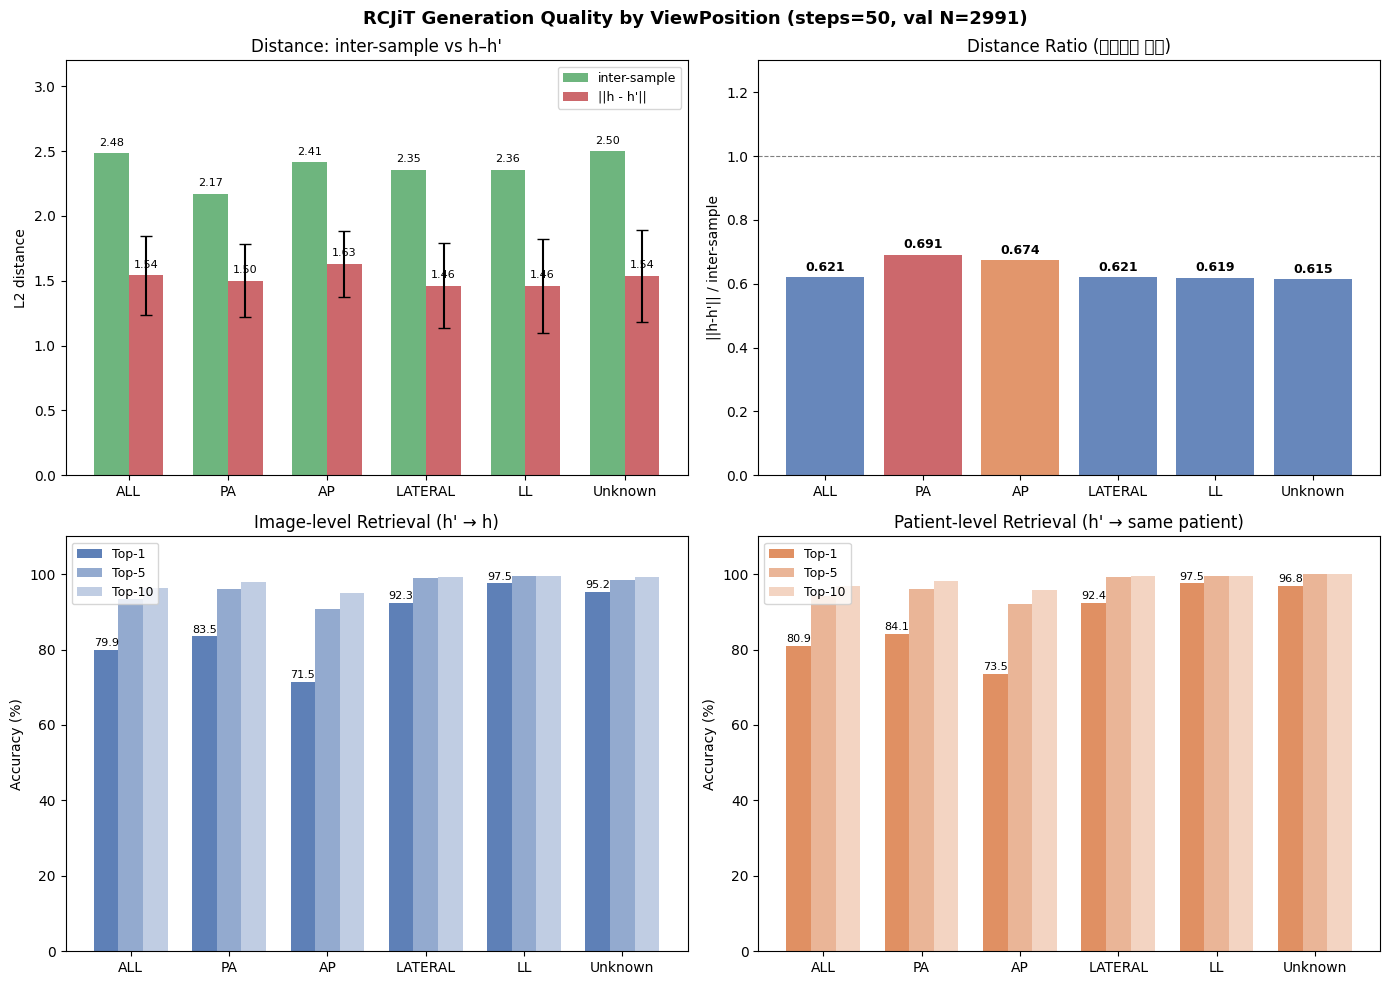

In [35]:
import matplotlib.pyplot as plt
import numpy as np

labels_vp = ["ALL", "PA", "AP", "LATERAL", "LL", "Unknown"]
N_counts  = [2991,  747, 1212,  633,        275,  124]
inter     = [2.4828, 2.1730, 2.4134, 2.3543, 2.3576, 2.4979]
hh_mean   = [1.5416, 1.5011, 1.6278, 1.4609, 1.4599, 1.5364]
hh_std    = [0.3028, 0.2815, 0.2552, 0.3286, 0.3646, 0.3529]
ratio     = [0.621,  0.691,  0.674,  0.621,  0.619,  0.615]
img_top1  = [79.9, 83.5, 71.5, 92.3, 97.5, 95.2]
img_top5  = [93.4, 96.0, 90.8, 98.9, 99.6, 98.4]
img_top10 = [96.4, 97.9, 95.0, 99.2, 99.6, 99.2]
pat_top1  = [80.9, 84.1, 73.5, 92.4, 97.5, 96.8]
pat_top5  = [94.1, 96.1, 92.1, 99.2, 99.6, 100.0]
pat_top10 = [96.8, 98.1, 95.7, 99.4, 99.6, 100.0]

x = np.arange(len(labels_vp))
c_img, c_pat = "#4C72B0", "#DD8452"
w = 0.25

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("RCJiT Generation Quality by ViewPosition (steps=50, val N=2991)", fontsize=13, fontweight="bold")

ax = axes[0, 0]
ax.bar(x - 0.175, inter,   0.35, label="inter-sample", color="#55A868", alpha=0.85)
ax.bar(x + 0.175, hh_mean, 0.35, label="||h - h'||",   color="#C44E52", alpha=0.85,
       yerr=hh_std, capsize=4)
ax.set_xticks(x); ax.set_xticklabels(labels_vp)
ax.set_ylabel("L2 distance"); ax.set_title("Distance: inter-sample vs h–h'")
ax.legend(fontsize=9); ax.set_ylim(0, 3.2)
for i,(iv,hv) in enumerate(zip(inter, hh_mean)):
    ax.text(i-0.175, iv+0.06, f"{iv:.2f}", ha="center", fontsize=8)
    ax.text(i+0.175, hv+0.06, f"{hv:.2f}", ha="center", fontsize=8)

ax = axes[0, 1]
ax.bar(x, ratio, color=["#4C72B0" if r<0.65 else "#DD8452" if r<0.68 else "#C44E52" for r in ratio], alpha=0.85)
ax.axhline(1.0, color="gray", linestyle="--", linewidth=0.8)
ax.set_xticks(x); ax.set_xticklabels(labels_vp)
ax.set_ylabel("||h-h'|| / inter-sample"); ax.set_title("Distance Ratio (낮을수록 좋음)")
ax.set_ylim(0, 1.3)
for i,r in enumerate(ratio):
    ax.text(i, r+0.02, f"{r:.3f}", ha="center", fontsize=9, fontweight="bold")

ax = axes[1, 0]
ax.bar(x-w, img_top1, w, label="Top-1", color=c_img, alpha=0.9)
ax.bar(x,   img_top5, w, label="Top-5", color=c_img, alpha=0.6)
ax.bar(x+w, img_top10,w, label="Top-10",color=c_img, alpha=0.35)
ax.set_xticks(x); ax.set_xticklabels(labels_vp)
ax.set_ylabel("Accuracy (%)"); ax.set_title("Image-level Retrieval (h' → h)")
ax.legend(fontsize=9); ax.set_ylim(0, 110)
for i,v in enumerate(img_top1): ax.text(i-w, v+1, f"{v:.1f}", ha="center", fontsize=8)

ax = axes[1, 1]
ax.bar(x-w, pat_top1, w, label="Top-1", color=c_pat, alpha=0.9)
ax.bar(x,   pat_top5, w, label="Top-5", color=c_pat, alpha=0.6)
ax.bar(x+w, pat_top10,w, label="Top-10",color=c_pat, alpha=0.35)
ax.set_xticks(x); ax.set_xticklabels(labels_vp)
ax.set_ylabel("Accuracy (%)"); ax.set_title("Patient-level Retrieval (h' → same patient)")
ax.legend(fontsize=9); ax.set_ylim(0, 110)
for i,v in enumerate(pat_top1): ax.text(i-w, v+1, f"{v:.1f}", ha="center", fontsize=8)

plt.tight_layout()
plt.savefig("rcjit_viewpos_stats.png", dpi=150, bbox_inches="tight")
plt.show()

Atelectasis                     N= 528  pos=1.6339±0.2860  neg=1.5749±0.2667
Cardiomegaly                    N= 534  pos=1.6397±0.2667  neg=1.5734±0.2706
Consolidation                   N= 113  pos=1.7067±0.2636  neg=1.5805±0.2703
Edema                           N= 326  pos=1.7310±0.3107  neg=1.5675±0.2603
Enlarged Cardiomediastinum      N=  90  pos=1.6468±0.2277  neg=1.5834±0.2721
Fracture                        N=  34  pos=1.5822±0.2631  neg=1.5853±0.2712
Lung Lesion                     N= 109  pos=1.6096±0.2531  neg=1.5844±0.2717
Lung Opacity                    N= 560  pos=1.6469±0.2735  neg=1.5711±0.2686
No Finding                      N=1129  pos=1.5160±0.2475  neg=1.6273±0.2762
Pleural Effusion                N= 670  pos=1.6648±0.2912  neg=1.5623±0.2606
Pleural Other                   N=  22  pos=1.6070±0.2366  neg=1.5851±0.2713
Pneumonia                       N= 194  pos=1.6169±0.2705  neg=1.5831±0.2710
Pneumothorax                    N= 112  pos=1.6490±0.2151  neg=1.5828±0.2727

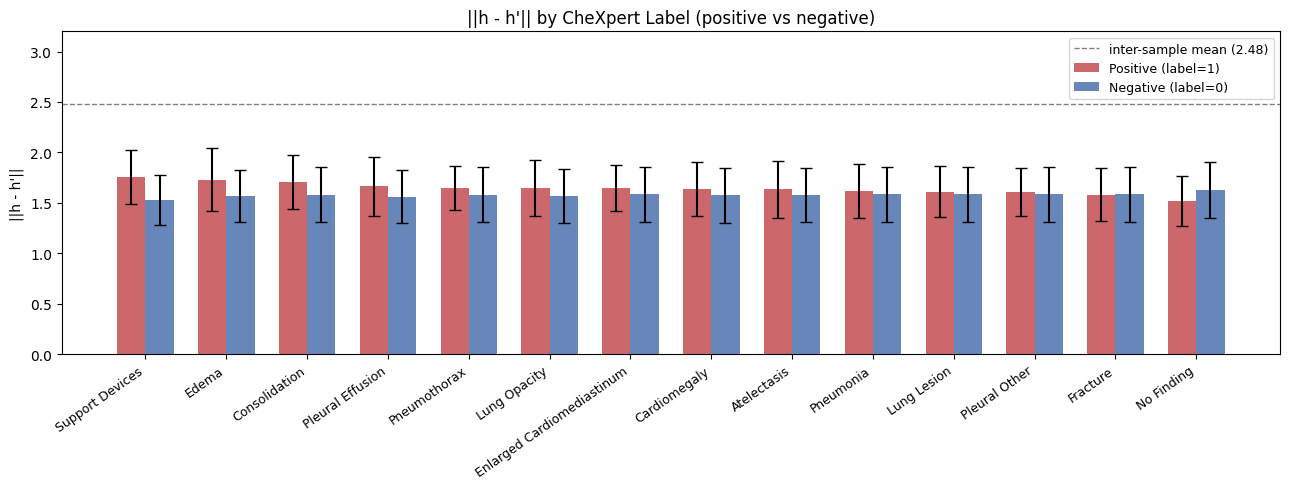

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

CHEXPERT_LABELS = [
    "Atelectasis", "Cardiomegaly", "Consolidation", "Edema",
    "Enlarged Cardiomediastinum", "Fracture", "Lung Lesion",
    "Lung Opacity", "No Finding", "Pleural Effusion",
    "Pleural Other", "Pneumonia", "Pneumothorax", "Support Devices"
]

label_arr = torch.from_numpy(
    dataset_rcjit.dataset.df[CHEXPERT_LABELS].values.astype("float32")
)  # (N, 14)

# ||h - h'|| per sample
sq   = (all_h  ** 2).sum(1, keepdim=True)
sq_p = (all_hp ** 2).sum(1, keepdim=True)
dist_self = (sq + sq_p - 2 * (all_h * all_hp).sum(1, keepdim=True)).clamp(0).sqrt().squeeze(1)  # (N,)

# inter-sample 전체 평균 (기준선)
inter_mean = 2.4828

rows = []
for i, lname in enumerate(CHEXPERT_LABELS):
    pos_mask = label_arr[:, i] == 1
    neg_mask = label_arr[:, i] == 0
    n_pos = pos_mask.sum().item()
    n_neg = neg_mask.sum().item()
    if n_pos < 5:
        continue
    d_pos = dist_self[pos_mask]
    d_neg = dist_self[neg_mask]
    rows.append({
        "label": lname,
        "N_pos": n_pos,
        "pos_mean": d_pos.mean().item(),
        "pos_std":  d_pos.std().item(),
        "neg_mean": d_neg.mean().item(),
        "neg_std":  d_neg.std().item(),
    })
    print(f"{lname:30s}  N={n_pos:4d}  pos={d_pos.mean():.4f}±{d_pos.std():.4f}  neg={d_neg.mean():.4f}±{d_neg.std():.4f}")

# ── 시각화 ─────────────────────────────────────────────────────────────────────
df_r = pd.DataFrame(rows).sort_values("pos_mean", ascending=False)

fig, ax = plt.subplots(figsize=(13, 5))
x = np.arange(len(df_r))
w = 0.35
ax.bar(x - w/2, df_r["pos_mean"], w, yerr=df_r["pos_std"], capsize=4,
       label="Positive (label=1)", color="#C44E52", alpha=0.85)
ax.bar(x + w/2, df_r["neg_mean"], w, yerr=df_r["neg_std"], capsize=4,
       label="Negative (label=0)", color="#4C72B0", alpha=0.85)
ax.axhline(inter_mean, color="gray", linestyle="--", linewidth=1, label=f"inter-sample mean ({inter_mean:.2f})")
ax.set_xticks(x)
ax.set_xticklabels(df_r["label"], rotation=35, ha="right", fontsize=9)
ax.set_ylabel("||h - h'||")
ax.set_title("||h - h'|| by CheXpert Label (positive vs negative)")
ax.legend(fontsize=9)
ax.set_ylim(0, 3.2)
plt.tight_layout()
plt.savefig("rcjit_label_stats.png", dpi=150, bbox_inches="tight")
plt.show()

In [37]:
matplotlib
all_h[0].cpu().numpy()

NameError: name 'matplotlib' is not defined

In [39]:
all_hp[0].std()

tensor(0.4844)

In [38]:
import numpy as np
import torch


def save_representations(all_h, all_hp, dataset, save_dir="."):
    """
    all_h, all_hp : torch.Tensor (N, D) — encoder representations
    dataset       : FromTorchDataset wrapping MIMICCXRDataset
                    (dataset.dataset.df 에 subject_id, study_id, dicom_id 있어야 함)
    save_dir      : 저장 경로

    저장 파일:
        vit_s_16_h.npz  — {'h': (N, D), 'paths': (N,)}
        vit_s_16_hp.npz — {'hp': (N, D), 'paths': (N,)}
    """
    import os

    df = dataset.dataset.df
    paths = np.array([dataset.dataset._get_image_path(df.iloc[i]) for i in range(len(df))])

    h_np  = all_h .cpu().numpy() if isinstance(all_h,  torch.Tensor) else all_h
    hp_np = all_hp.cpu().numpy() if isinstance(all_hp, torch.Tensor) else all_hp

    assert len(paths) == len(h_np) == len(hp_np), \
        f"길이 불일치: paths={len(paths)}, h={len(h_np)}, hp={len(hp_np)}"

    out_h  = os.path.join(save_dir, "vit_s_16_h.npz")
    out_hp = os.path.join(save_dir, "vit_s_16_hp.npz")

    np.savez(out_h,  h=h_np,   paths=paths)
    np.savez(out_hp, hp=hp_np, paths=paths)

    print(f"Saved {len(paths)} samples")
    print(f"  {out_h}   shape={h_np.shape}")
    print(f"  {out_hp}  shape={hp_np.shape}")
    print(f"  예시 path: {paths[0]}")
save_representations(all_h, all_hp, dataset_rcjit)

Saved 2991 samples
  ./vit_s_16_h.npz   shape=(2991, 384)
  ./vit_s_16_hp.npz  shape=(2991, 384)
  예시 path: /mnt/nvme1/mimic-cxr-jpg/files/p10/p10003502/s50084553/70d7e600-373c1311-929f5ff9-23ee3621-ff551ff9.jpg
